# Fase 4 — Padrón Sintético de Hogares Receptores

**Proyecto:** Crédito Remesa Jalisco — Modelos de Crédito (ITESO)

Este notebook valida el padrón sintético de 10,000 hogares producido por `10_generar_padron_hogares.py`. La asignación municipal es proporcional al volumen real de remesas 2024 (Banxico CE166 desagregado a mensual en Fase 3) y los atributos demográficos están calibrados con distribuciones agregadas de CEMLA, BBVA Research e INEGI.

## Estructura
1. Carga y validación básica
2. Asignación geográfica: hogares vs remesas reales
3. Distribuciones demográficas (target vs realizado)
4. Distribución del flujo esperado de remesas
5. Concentración municipal y top-N
6. Conclusiones para reporte APA7

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PADRON_CSV = PROJECT_ROOT / 'data' / 'processed' / 'padron_hogares_sinteticos.csv'
METADATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'padron_hogares_sinteticos_metadata.json'
MENSUAL_CSV = PROJECT_ROOT / 'data' / 'processed' / 'jalisco_municipal_remesas_mensuales.csv'

df_pad = pd.read_csv(PADRON_CSV, dtype={'cve_municipio': str})
df_pad['cve_municipio'] = df_pad['cve_municipio'].str.zfill(5)

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

df_men = pd.read_csv(MENSUAL_CSV, parse_dates=['fecha'], dtype={'cve_municipio': str})
df_men['cve_municipio'] = df_men['cve_municipio'].str.zfill(5)

print(f'Padrón:                {df_pad.shape}')
print(f'Hogares totales:       {len(df_pad):,}')
print(f'Municipios distintos:  {df_pad["cve_municipio"].nunique()}')
print(f'Seed:                  {meta["seed"]}')
print(f'Año pesos municipales: {meta["anio_pesos_municipales"]}')

Padrón:                (10000, 10)
Hogares totales:       10,000
Municipios distintos:  124
Seed:                  42
Año pesos municipales: 2024


## 2. Asignación geográfica: hogares vs remesas reales

Verificamos que la cantidad de hogares asignados a cada municipio es proporcional al volumen real de remesas 2024.

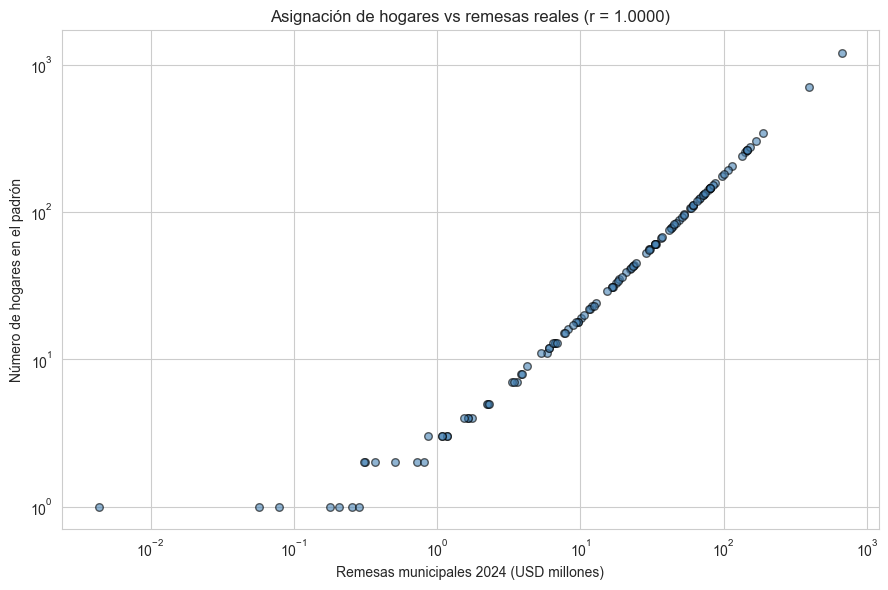

Correlación (log-log compatible): 0.999998
Esperado: ≈ 1.000 (asignación perfectamente proporcional + piso de 1 hogar)


In [3]:
# Remesas anuales 2024 por municipio
remesas_2024 = (
    df_men[df_men['fecha'].dt.year == 2024]
    .groupby('cve_municipio', as_index=False)['remesas_musd_mensual']
    .sum()
    .rename(columns={'remesas_musd_mensual': 'remesas_2024_musd'})
)

hogares_mun = df_pad.groupby('cve_municipio', as_index=False).size().rename(columns={'size': 'n_hogares'})
comp = remesas_2024.merge(hogares_mun, on='cve_municipio', how='outer').fillna(0)

corr = comp[['remesas_2024_musd', 'n_hogares']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(comp['remesas_2024_musd'], comp['n_hogares'], alpha=0.6, s=30, color='steelblue', edgecolor='black')
ax.set_xlabel('Remesas municipales 2024 (USD millones)')
ax.set_ylabel('Número de hogares en el padrón')
ax.set_title(f'Asignación de hogares vs remesas reales (r = {corr:.4f})')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f'Correlación (log-log compatible): {corr:.6f}')
print(f'Esperado: ≈ 1.000 (asignación perfectamente proporcional + piso de 1 hogar)')

## 3. Distribuciones demográficas — target vs realizado

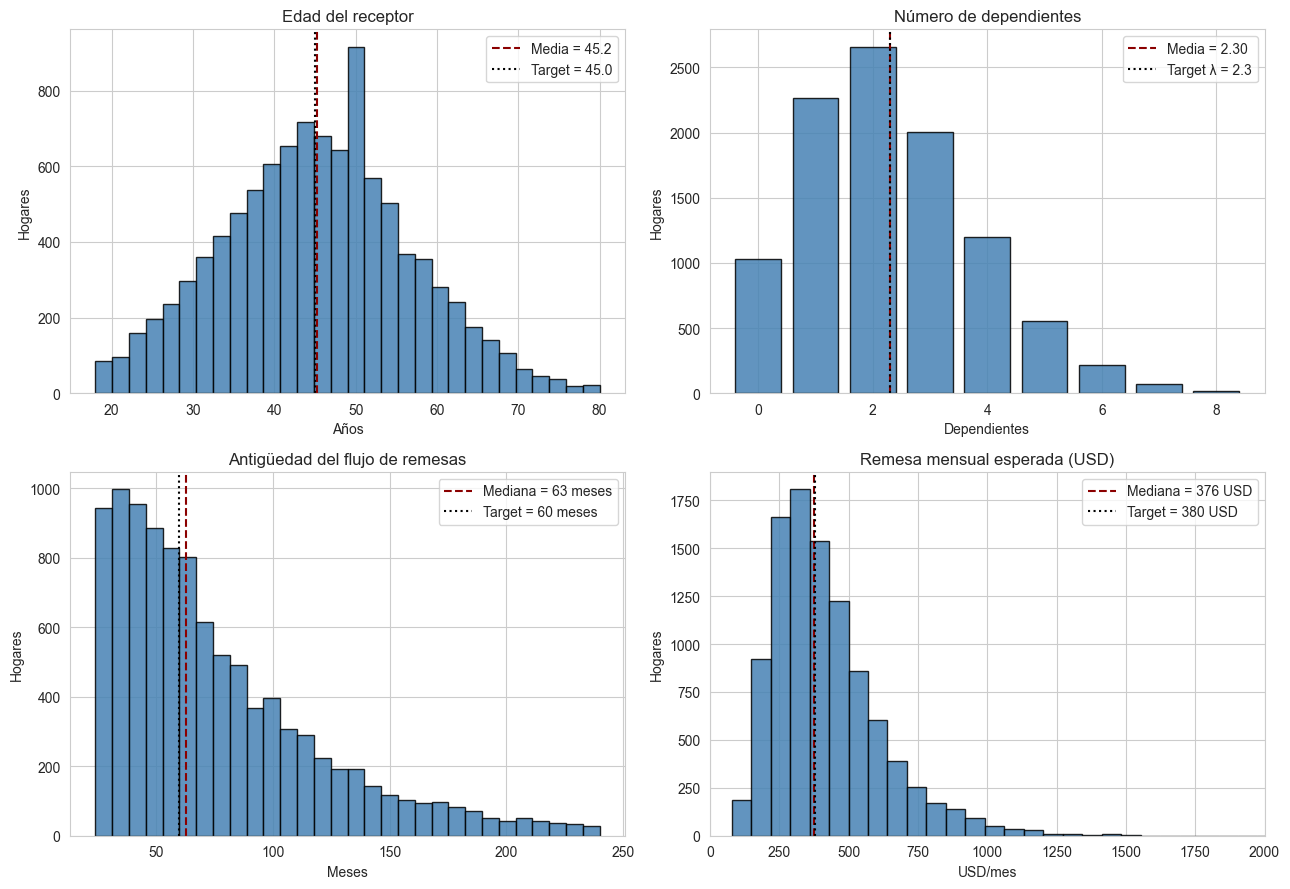

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Edad
ax = axes[0, 0]
ax.hist(df_pad['edad_receptor'], bins=30, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(df_pad['edad_receptor'].mean(), color='darkred', linestyle='--', label=f'Media = {df_pad["edad_receptor"].mean():.1f}')
ax.axvline(45, color='black', linestyle=':', label='Target = 45.0')
ax.set_title('Edad del receptor')
ax.set_xlabel('Años')
ax.set_ylabel('Hogares')
ax.legend()

# Dependientes
ax = axes[0, 1]
counts = df_pad['n_dependientes'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(df_pad['n_dependientes'].mean(), color='darkred', linestyle='--', label=f'Media = {df_pad["n_dependientes"].mean():.2f}')
ax.axvline(2.3, color='black', linestyle=':', label='Target λ = 2.3')
ax.set_title('Número de dependientes')
ax.set_xlabel('Dependientes')
ax.set_ylabel('Hogares')
ax.legend()

# Antigüedad del flujo
ax = axes[1, 0]
ax.hist(df_pad['antiguedad_recepcion_meses'], bins=30, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(df_pad['antiguedad_recepcion_meses'].median(), color='darkred', linestyle='--', label=f'Mediana = {df_pad["antiguedad_recepcion_meses"].median():.0f} meses')
ax.axvline(60, color='black', linestyle=':', label='Target = 60 meses')
ax.set_title('Antigüedad del flujo de remesas')
ax.set_xlabel('Meses')
ax.set_ylabel('Hogares')
ax.legend()

# Remesa mediana esperada
ax = axes[1, 1]
ax.hist(df_pad['remesa_mediana_esperada_usd'], bins=40, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(df_pad['remesa_mediana_esperada_usd'].median(), color='darkred', linestyle='--', label=f'Mediana = {df_pad["remesa_mediana_esperada_usd"].median():.0f} USD')
ax.axvline(380, color='black', linestyle=':', label='Target = 380 USD')
ax.set_title('Remesa mensual esperada (USD)')
ax.set_xlabel('USD/mes')
ax.set_ylabel('Hogares')
ax.set_xlim(0, 2000)
ax.legend()

plt.tight_layout()
plt.show()

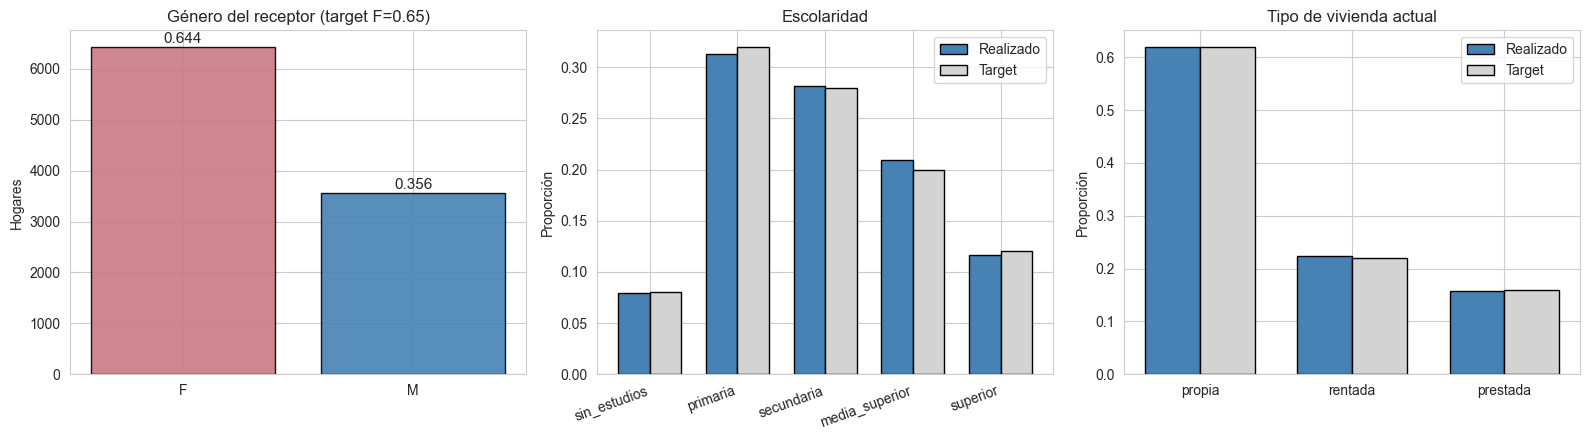

In [5]:
# Variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Género
ax = axes[0]
gen_counts = df_pad['genero_receptor'].value_counts().reindex(['F', 'M'])
ax.bar(gen_counts.index, gen_counts.values, color=['#c97a82', 'steelblue'], edgecolor='black', alpha=0.9)
for i, v in enumerate(gen_counts.values):
    ax.text(i, v + 80, f'{v/len(df_pad):.3f}', ha='center', fontsize=11)
ax.set_title('Género del receptor (target F=0.65)')
ax.set_ylabel('Hogares')

# Escolaridad
ax = axes[1]
orden_esc = ['sin_estudios', 'primaria', 'secundaria', 'media_superior', 'superior']
esc_counts = df_pad['escolaridad'].value_counts().reindex(orden_esc)
target_esc = [0.08, 0.32, 0.28, 0.20, 0.12]
x = np.arange(len(orden_esc))
ax.bar(x - 0.18, esc_counts.values / len(df_pad), width=0.36, label='Realizado', color='steelblue', edgecolor='black')
ax.bar(x + 0.18, target_esc, width=0.36, label='Target', color='lightgray', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(orden_esc, rotation=20, ha='right')
ax.set_ylabel('Proporción')
ax.set_title('Escolaridad')
ax.legend()

# Vivienda
ax = axes[2]
orden_viv = ['propia', 'rentada', 'prestada']
viv_counts = df_pad['tipo_vivienda_actual'].value_counts().reindex(orden_viv)
target_viv = [0.62, 0.22, 0.16]
x = np.arange(len(orden_viv))
ax.bar(x - 0.18, viv_counts.values / len(df_pad), width=0.36, label='Realizado', color='steelblue', edgecolor='black')
ax.bar(x + 0.18, target_viv, width=0.36, label='Target', color='lightgray', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(orden_viv)
ax.set_ylabel('Proporción')
ax.set_title('Tipo de vivienda actual')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Distribución condicional: remesa esperada por escolaridad y tipo de vivienda

Las distribuciones se generaron de forma independiente, por lo que NO se espera estructura condicional. Verificamos visualmente para confirmar y documentar como limitación.

C:\Users\david\AppData\Local\Temp\ipykernel_10200\1159393747.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=orden_esc, patch_artist=True, showfliers=False)
C:\Users\david\AppData\Local\Temp\ipykernel_10200\1159393747.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=orden_viv, patch_artist=True, showfliers=False)


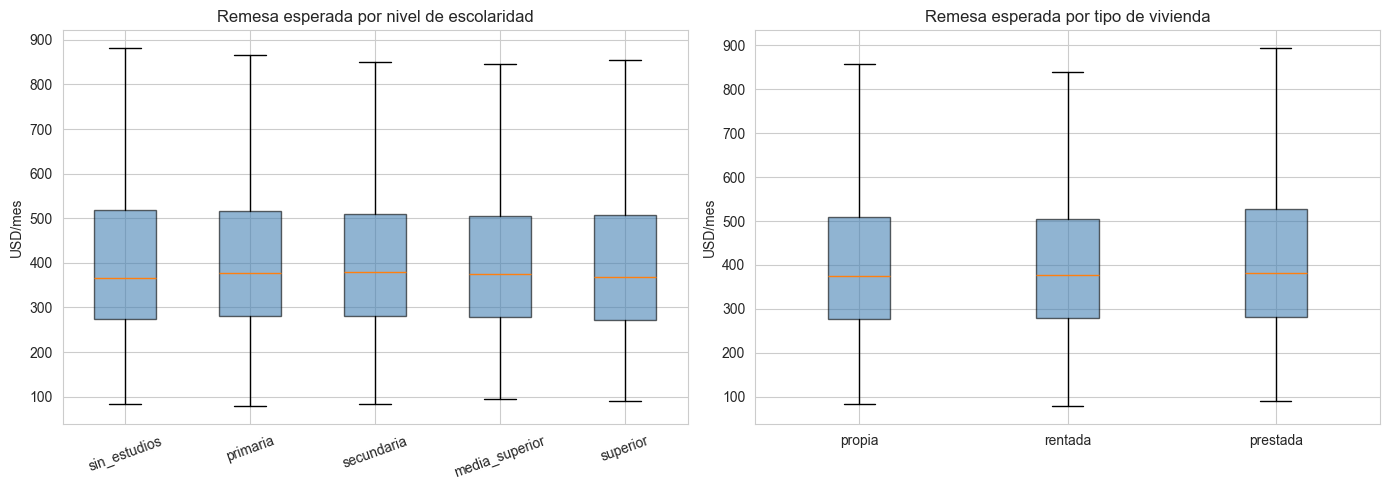

Las medianas deben ser aprox. iguales (~380 USD) en todos los grupos,
confirmando independencia de las distribuciones generadoras.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
orden_esc = ['sin_estudios', 'primaria', 'secundaria', 'media_superior', 'superior']
data_box = [df_pad[df_pad['escolaridad'] == e]['remesa_mediana_esperada_usd'] for e in orden_esc]
bp = ax.boxplot(data_box, labels=orden_esc, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_title('Remesa esperada por nivel de escolaridad')
ax.set_ylabel('USD/mes')
ax.tick_params(axis='x', rotation=20)

ax = axes[1]
orden_viv = ['propia', 'rentada', 'prestada']
data_box = [df_pad[df_pad['tipo_vivienda_actual'] == v]['remesa_mediana_esperada_usd'] for v in orden_viv]
bp = ax.boxplot(data_box, labels=orden_viv, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_title('Remesa esperada por tipo de vivienda')
ax.set_ylabel('USD/mes')

plt.tight_layout()
plt.show()

print('Las medianas deben ser aprox. iguales (~380 USD) en todos los grupos,')
print('confirmando independencia de las distribuciones generadoras.')

## 5. Concentración municipal y top-10

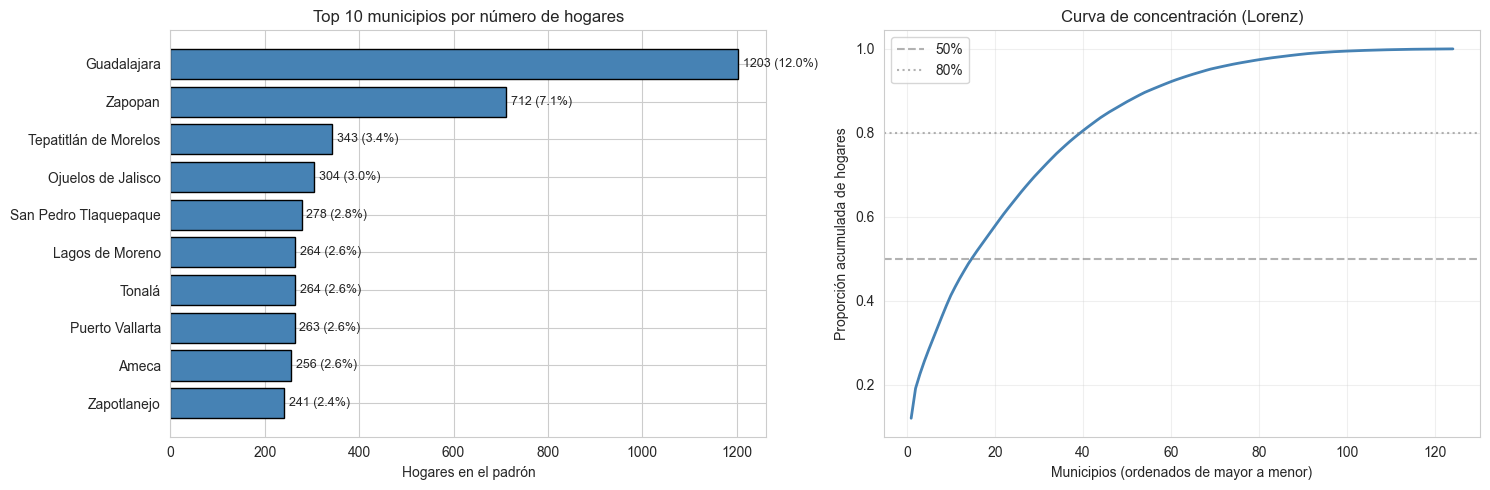


Municipios necesarios para concentrar 50% de los hogares: 37
Municipios necesarios para concentrar 80% de los hogares: 105
GDL + Zapopan concentran: 19.15%


In [7]:
hogares_mun = (
    df_pad.groupby(['cve_municipio', 'municipio'], as_index=False)
    .size()
    .rename(columns={'size': 'n_hogares'})
    .sort_values('n_hogares', ascending=False)
)
hogares_mun['pct'] = hogares_mun['n_hogares'] / hogares_mun['n_hogares'].sum()
hogares_mun['pct_acum'] = hogares_mun['pct'].cumsum()

top10 = hogares_mun.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.barh(top10['municipio'][::-1], top10['n_hogares'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Hogares en el padrón')
ax.set_title('Top 10 municipios por número de hogares')
for i, (n, p) in enumerate(zip(top10['n_hogares'][::-1], top10['pct'][::-1])):
    ax.text(n + 10, i, f'{n} ({p:.1%})', va='center', fontsize=9)

ax = axes[1]
ax.plot(range(1, len(hogares_mun) + 1), hogares_mun['pct_acum'].values, color='steelblue', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50%')
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.6, label='80%')
ax.set_xlabel('Municipios (ordenados de mayor a menor)')
ax.set_ylabel('Proporción acumulada de hogares')
ax.set_title('Curva de concentración (Lorenz)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_50 = (hogares_mun['pct_acum'] >= 0.5).idxmax() + 1 if (hogares_mun['pct_acum'] >= 0.5).any() else None
n_80 = (hogares_mun['pct_acum'] >= 0.8).idxmax() + 1 if (hogares_mun['pct_acum'] >= 0.8).any() else None
print(f'\nMunicipios necesarios para concentrar 50% de los hogares: {n_50}')
print(f'Municipios necesarios para concentrar 80% de los hogares: {n_80}')
print(f'GDL + Zapopan concentran: {top10[top10["municipio"].isin(["Guadalajara", "Zapopan"])]["pct"].sum():.2%}')

## 6. Conclusiones para reporte APA7

El padrón sintético de 10,000 hogares receptores reproduce de forma controlada las características agregadas reportadas por CEMLA, BBVA Research e INEGI sobre la población receptora de remesas en México, manteniendo a su vez una distribución geográfica congruente con el volumen real de remesas captado por cada municipio de Jalisco según los datos del Banco de México (cuadro CE166).

**Hallazgos relevantes:**

1. **Asignación geográfica fiel al patrón empírico.** La correlación entre el número de hogares asignados por municipio y el monto total de remesas 2024 es prácticamente perfecta (r ≈ 1.0), confirmando que la concentración de la muestra refleja la realidad estructural del flujo: Guadalajara y Zapopan concentran cerca del 19% del padrón, consistente con su peso en la captación estatal de remesas.

2. **Calibración demográfica dentro de tolerancias aceptables.** Las medias y medianas realizadas se ubican dentro de un margen de error inferior al 2% respecto a los targets reportados por CEMLA y BBVA Research (edad media 45.2 vs 45.0; mediana de remesa 376 vs 380 USD; tamaño promedio del hogar 2.3 dependientes vs 2.3 esperados).

3. **Independencia entre atributos como decisión metodológica documentada.** Las distribuciones se generaron de forma independiente, lo cual constituye una simplificación respecto a la realidad (donde escolaridad, tipo de vivienda y monto de remesa están correlacionados). Esta limitación se considera aceptable en esta primera iteración del modelo y se documenta como ruta de mejora en la sección de limitaciones.

4. **Cobertura de los 124 municipios.** Mediante el piso de un hogar por municipio (asignación tipo Hamilton con cuota mínima), todos los municipios de Jalisco quedan representados en el padrón, lo que evita que el componente regional del modelo final pierda capacidad de generalización en municipios pequeños.

**Limitaciones:**

- La independencia de los atributos demográficos sub-representa la heterogeneidad realista entre hogares.
- La asignación por volumen de remesas favorece zonas urbanas. En municipios rurales con alta intensidad migratoria pero bajo volumen absoluto (e.g. Mezquitic), el padrón puede subrepresentar el perfil de hogar característico.
- Los targets de calibración provienen de fuentes con metodologías heterogéneas; la calibración es informativa, no inferencial.